# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'
#mod='t0zero'
#mode=sys.argv[2]
GM0 = 2.79284356
GE0 = 1

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GE0 = 1
GM0 = 2.792847356
GEp0 = 1
GMp0 = 2.792847356
GEn0 = 1
GMn0 = -1.91304272
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load World+Pol+Mainz Sum-Rules baseline Fitting Results

In [4]:
fit_date='sep272019'
rad_cons = 'RE8414_RM851'

In [5]:
##Load Q2max=1000 Fitting results#{{{
folder = '../%s_all_FF/z'%fit_date+str(kmax) # folder containing central fits
#filename=folder+'/Round6_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_'+rad_cons+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
Z = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err = np.zeros(N, dtype=float)
GM_err = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)
GE_err_rat = np.zeros(N, dtype=float)
GM_err_rat = np.zeros(N, dtype=float)
GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
    Z[i]=float(values[1])

    GE_fit[i]=float(values[2])
    GE_pos[i]=float(values[2])+abs(float(values[3]))
    GE_neg[i]=float(values[2])-abs(float(values[3]))
    GM_fit[i]=float(values[4])
    GM_pos[i]=float(values[4])+abs(float(values[5]))
    GM_neg[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat[i]=float(values[6])
    GE_pos_rat[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat[i]=float(values[8])
    GM_pos_rat[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat[i]=float(values[10])+abs(GEGM_err1)
    GEGM_neg_rat[i]=float(values[10])-abs(GEGM_err1)
 
    GEd[i] = GD(Q2[i]) * GE0
    GMd[i] = GD(Q2[i]) * GM0
    GE_err[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err[i] = GEGM_err1/float(values[10])
    GE_err_rat[i] = abs(float(values[7]) ) #/ abs(float(values[2]))
    GM_err_rat[i] = abs(float(values[9]) ) #/ abs(float(values[4]))

    #if Q2[i]>9.0 and Q2[i]<12.0:
    #    print 'Q2=%e,  GEp_ALL=%e'%(Q2[i],GE_fit_rat[i])
        
values = fitlines[2016].split()
erad = float(values[0])
derad = float(values[1])
mrad = float(values[2])
dmrad = float(values[3])

values = fitlines[2015].split()
ndof = float(values[0])
num_tot = float(values[1])
num_Mainz = float(values[2])
num_world = float(values[3])
num_pol = float(values[4])

values = fitlines[2014].split()
redchi2 = float(values[0])
chi2 = float(values[1])
chi2xsMainz = float(values[2])
chi2xsworld = float(values[3])
chi2pol = float(values[4])
chi2gecoef = float(values[5])
chi2gmcoef = float(values[6])
chi2csyst = float(values[7])
chi2NMainz = float(values[8])
chi2Nworld = float(values[9])
chi2gefake= float(values[10])
chi2gmfake= float(values[11])
chi2gefakeHQ= float(values[12])
chi2gmfakeHQ= float(values[13])

#}}}

file exist ../sep272019_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_RE8414_RM851.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results

In [6]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_'+rad_cons+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP = np.zeros(N, dtype=float)
GE_fit_WP = np.zeros(N, dtype=float)
GE_pos_WP = np.zeros(N, dtype=float)
GE_neg_WP = np.zeros(N, dtype=float)
GM_fit_WP = np.zeros(N, dtype=float)
GM_pos_WP = np.zeros(N, dtype=float)
GM_neg_WP = np.zeros(N, dtype=float)
GE_fit_rat_WP = np.zeros(N, dtype=float)
GE_pos_rat_WP = np.zeros(N, dtype=float)
GE_neg_rat_WP = np.zeros(N, dtype=float)
GM_fit_rat_WP = np.zeros(N, dtype=float)
GM_pos_rat_WP = np.zeros(N, dtype=float)
GM_neg_rat_WP = np.zeros(N, dtype=float)
GEGM_fit_rat_WP = np.zeros(N, dtype=float)
GEGM_pos_rat_WP = np.zeros(N, dtype=float)
GEGM_neg_rat_WP = np.zeros(N, dtype=float)
GE_err_WP = np.zeros(N, dtype=float)
GM_err_WP = np.zeros(N, dtype=float)
GEGM_err_WP = np.zeros(N, dtype=float)
GE_err_rat_WP = np.zeros(N, dtype=float)
GM_err_rat_WP = np.zeros(N, dtype=float)
GEd_WP = np.zeros(N, dtype=float)
GMd_WP = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP[i]=float(values[0])
    GE_fit_WP[i]=float(values[2])
    GE_pos_WP[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP[i]=float(values[4])
    GM_pos_WP[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP[i]=float(values[6])
    GE_pos_rat_WP[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP[i]=float(values[8])
    GM_pos_rat_WP[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP[i] = GD(Q2_WP[i]) * GE0
    GMd_WP[i] = GD(Q2_WP[i]) * GM0
    GE_err_WP[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP[i] = GEGM_err_n1/float(values[10])
    GE_err_rat_WP[i] = abs(float(values[7]) ) 
    GM_err_rat_WP[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_WP = float(values[0])
derad_WP = float(values[1])
mrad_WP = float(values[2])
dmrad_WP = float(values[3])

values = fitlines[2015].split()
ndof_WP = float(values[0])
num_tot_WP = float(values[1])
num_Mainz_WP = float(values[2])
num_world_WP = float(values[3])
num_pol_WP = float(values[4])

values = fitlines[2014].split()
redchi2_WP = float(values[0])
chi2_WP = float(values[1])
chi2xsMainz_WP = float(values[2])
chi2xsworld_WP = float(values[3])
chi2pol_WP = float(values[4])
chi2gecoef_WP = float(values[5])
chi2gmcoef_WP = float(values[6])
chi2csyst_WP = float(values[7])
chi2NMainz_WP = float(values[8])
chi2Nworld_WP = float(values[9])
chi2gefake_WP = float(values[10])
chi2gmfake_WP = float(values[11])
chi2gefakeHQ_WP = float(values[12])
chi2gmfakeHQ_WP = float(values[13])

#}}}

file exist ../sep272019_world_FF/z12/out_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7_RE8414_RM851.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results w/o radius contraint

In [7]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP_noRad = np.zeros(N, dtype=float)
GE_fit_WP_noRad = np.zeros(N, dtype=float)
GE_pos_WP_noRad = np.zeros(N, dtype=float)
GE_neg_WP_noRad = np.zeros(N, dtype=float)
GM_fit_WP_noRad = np.zeros(N, dtype=float)
GM_pos_WP_noRad = np.zeros(N, dtype=float)
GM_neg_WP_noRad = np.zeros(N, dtype=float)
GE_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GE_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GE_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GM_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GM_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GM_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GE_err_WP_noRad = np.zeros(N, dtype=float)
GM_err_WP_noRad = np.zeros(N, dtype=float)
GEGM_err_WP_noRad = np.zeros(N, dtype=float)
GE_err_rat_WP_noRad = np.zeros(N, dtype=float)
GM_err_rat_WP_noRad = np.zeros(N, dtype=float)
GEd_WP_noRad = np.zeros(N, dtype=float)
GMd_WP_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP_noRad[i]=float(values[0])
    GE_fit_WP_noRad[i]=float(values[2])
    GE_pos_WP_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP_noRad[i]=float(values[4])
    GM_pos_WP_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP_noRad[i]=float(values[6])
    GE_pos_rat_WP_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP_noRad[i]=float(values[8])
    GM_pos_rat_WP_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP_noRad[i] = GD(Q2_WP_noRad[i]) * GE0
    GMd_WP_noRad[i] = GD(Q2_WP_noRad[i]) * GM0
    GE_err_WP_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP_noRad[i] = GEGM_err_n1/float(values[10])
    GE_err_rat_WP_noRad[i] = abs(float(values[7]) ) 
    GM_err_rat_WP_noRad[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_WP_noRad = float(values[0])
derad_WP_noRad = float(values[1])
mrad_WP_noRad = float(values[2])
dmrad_WP_noRad = float(values[3])

values = fitlines[2015].split()
ndof_WP_noRad = float(values[0])
num_tot_WP_noRad = float(values[1])
num_Mainz_WP_noRad = float(values[2])
num_world_WP_noRad = float(values[3])
num_pol_WP_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_WP_noRad = float(values[0])
chi2_WP_noRad = float(values[1])
chi2xsMainz_WP_noRad = float(values[2])
chi2xsworld_WP_noRad = float(values[3])
chi2pol_WP_noRad = float(values[4])
chi2gecoef_WP_noRad = float(values[5])
chi2gmcoef_WP_noRad = float(values[6])
chi2csyst_WP_noRad = float(values[7])
chi2NMainz_WP_noRad = float(values[8])
chi2Nworld_WP_noRad = float(values[9])
chi2gefake_WP_noRad = float(values[10])
chi2gmfake_WP_noRad = float(values[11])
chi2gefakeHQ_WP_noRad = float(values[12])
chi2gmfakeHQ_WP_noRad = float(values[13])

#}}}

file exist ../sep272019_world_FF/z12/out_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit Load Main-Only Sum-Rules baseline Fitting Results

In [8]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'Mainz'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_'+rad_cons+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_MZ = np.zeros(N, dtype=float)
GE_fit_MZ = np.zeros(N, dtype=float)
GE_pos_MZ = np.zeros(N, dtype=float)
GE_neg_MZ = np.zeros(N, dtype=float)
GM_fit_MZ = np.zeros(N, dtype=float)
GM_pos_MZ = np.zeros(N, dtype=float)
GM_neg_MZ = np.zeros(N, dtype=float)
GE_fit_rat_MZ = np.zeros(N, dtype=float)
GE_pos_rat_MZ = np.zeros(N, dtype=float)
GE_neg_rat_MZ = np.zeros(N, dtype=float)
GM_fit_rat_MZ = np.zeros(N, dtype=float)
GM_pos_rat_MZ = np.zeros(N, dtype=float)
GM_neg_rat_MZ = np.zeros(N, dtype=float)
GEGM_fit_rat_MZ = np.zeros(N, dtype=float)
GEGM_pos_rat_MZ = np.zeros(N, dtype=float)
GEGM_neg_rat_MZ = np.zeros(N, dtype=float)
GE_err_MZ = np.zeros(N, dtype=float)
GM_err_MZ = np.zeros(N, dtype=float)
GEGM_err_MZ = np.zeros(N, dtype=float)

GEd_MZ = np.zeros(N, dtype=float)
GMd_MZ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_MZ[i]=float(values[0])
    GE_fit_MZ[i]=float(values[2])
    GE_pos_MZ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_MZ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_MZ[i]=float(values[4])
    GM_pos_MZ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_MZ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_MZ[i]=float(values[6])
    GE_pos_rat_MZ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_MZ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_MZ[i]=float(values[8])
    GM_pos_rat_MZ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_MZ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_MZ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_MZ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_MZ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_MZ[i] = GD(Q2_MZ[i]) * GE0
    GMd_MZ[i] = GD(Q2_MZ[i]) * GM0
    GE_err_MZ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_MZ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_MZ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_MZ = float(values[0])
derad_MZ = float(values[1])
mrad_MZ = float(values[2])
dmrad_MZ = float(values[3])

values = fitlines[2015].split()
ndof_MZ = float(values[0])
num_tot_MZ = float(values[1])
num_Mainz_MZ = float(values[2])
num_world_MZ = float(values[3])
num_pol_MZ = float(values[4])

values = fitlines[2014].split()
redchi2_MZ = float(values[0])
chi2_MZ = float(values[1])
chi2xsMainz_MZ = float(values[2])
chi2xsworld_MZ = float(values[3])
chi2pol_MZ = float(values[4])
chi2gecoef_MZ = float(values[5])
chi2gmcoef_MZ = float(values[6])
chi2csyst_MZ = float(values[7])
chi2NMainz_MZ = float(values[8])
chi2Nworld_MZ = float(values[9])
chi2gefake_MZ = float(values[10])
chi2gmfake_MZ = float(values[11])
chi2gefakeHQ_MZ = float(values[12])
chi2gmfakeHQ_MZ = float(values[13])

#}}}

file exist ../sep272019_Mainz_FF/z12/out_Mainz_sumrules_leastsq_Q21000_z12_gb5_t0fix7_RE8414_RM851.dat


## Fit w/o radius contraints

In [9]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noRad = np.zeros(N, dtype=float)
GE_fit_noRad = np.zeros(N, dtype=float)
GE_pos_noRad = np.zeros(N, dtype=float)
GE_neg_noRad = np.zeros(N, dtype=float)
GM_fit_noRad = np.zeros(N, dtype=float)
GM_pos_noRad = np.zeros(N, dtype=float)
GM_neg_noRad = np.zeros(N, dtype=float)
GE_fit_rat_noRad = np.zeros(N, dtype=float)
GE_pos_rat_noRad = np.zeros(N, dtype=float)
GE_neg_rat_noRad = np.zeros(N, dtype=float)
GM_fit_rat_noRad = np.zeros(N, dtype=float)
GM_pos_rat_noRad = np.zeros(N, dtype=float)
GM_neg_rat_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_noRad = np.zeros(N, dtype=float)
GE_err_noRad = np.zeros(N, dtype=float)
GM_err_noRad = np.zeros(N, dtype=float)
GEGM_err_noRad = np.zeros(N, dtype=float)

GE_err_rat_noRad = np.zeros(N, dtype=float)
GM_err_rat_noRad = np.zeros(N, dtype=float)

GEd_noRad = np.zeros(N, dtype=float)
GMd_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noRad[i]=float(values[0])
    GE_fit_noRad[i]=float(values[2])
    GE_pos_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noRad[i]=float(values[4])
    GM_pos_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noRad[i]=float(values[6])
    GE_pos_rat_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noRad[i]=float(values[8])
    GM_pos_rat_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noRad[i] = GD(Q2_noRad[i]) * GE0
    GMd_noRad[i] = GD(Q2_noRad[i]) * GM0
    GE_err_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noRad[i] = GEGM_err_n1/float(values[10])

    GE_err_rat_noRad[i] = abs(float(values[7]) )
    GM_err_rat_noRad[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_noRad = float(values[0])
derad_noRad = float(values[1])
mrad_noRad = float(values[2])
dmrad_noRad = float(values[3])

values = fitlines[2015].split()
ndof_noRad = float(values[0])
num_tot_noRad = float(values[1])
num_Mainz_noRad = float(values[2])
num_world_noRad = float(values[3])
num_pol_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_noRad = float(values[0])
chi2_noRad = float(values[1])
chi2xsMainz_noRad = float(values[2])
chi2xsworld_noRad = float(values[3])
chi2pol_noRad = float(values[4])
chi2gecoef_noRad = float(values[5])
chi2gmcoef_noRad = float(values[6])
chi2csyst_noRad = float(values[7])
chi2NMainz_noRad = float(values[8])
chi2Nworld_noRad = float(values[9])
chi2gefake_noRad = float(values[10])
chi2gmfake_noRad = float(values[11])
chi2gefakeHQ_noRad = float(values[12])
chi2gmfakeHQ_noRad = float(values[13])

#}}}

file exist ../sep272019_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit w/o Extra TPE contrains

In [10]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noTPE = np.zeros(N, dtype=float)
GE_fit_noTPE = np.zeros(N, dtype=float)
GE_pos_noTPE = np.zeros(N, dtype=float)
GE_neg_noTPE = np.zeros(N, dtype=float)
GM_fit_noTPE = np.zeros(N, dtype=float)
GM_pos_noTPE = np.zeros(N, dtype=float)
GM_neg_noTPE = np.zeros(N, dtype=float)
GE_fit_rat_noTPE = np.zeros(N, dtype=float)
GE_pos_rat_noTPE = np.zeros(N, dtype=float)
GE_neg_rat_noTPE = np.zeros(N, dtype=float)
GM_fit_rat_noTPE = np.zeros(N, dtype=float)
GM_pos_rat_noTPE = np.zeros(N, dtype=float)
GM_neg_rat_noTPE = np.zeros(N, dtype=float)
GEGM_fit_rat_noTPE = np.zeros(N, dtype=float)
GEGM_pos_rat_noTPE = np.zeros(N, dtype=float)
GEGM_neg_rat_noTPE = np.zeros(N, dtype=float)
GE_err_noTPE = np.zeros(N, dtype=float)
GM_err_noTPE = np.zeros(N, dtype=float)
GEGM_err_noTPE = np.zeros(N, dtype=float)

GEd_noTPE = np.zeros(N, dtype=float)
GMd_noTPE = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noTPE[i]=float(values[0])
    GE_fit_noTPE[i]=float(values[2])
    GE_pos_noTPE[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noTPE[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noTPE[i]=float(values[4])
    GM_pos_noTPE[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noTPE[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noTPE[i]=float(values[6])
    GE_pos_rat_noTPE[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noTPE[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noTPE[i]=float(values[8])
    GM_pos_rat_noTPE[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noTPE[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noTPE[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noTPE[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noTPE[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noTPE[i] = GD(Q2_noTPE[i]) * GE0
    GMd_noTPE[i] = GD(Q2_noTPE[i]) * GM0
    GE_err_noTPE[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noTPE[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noTPE[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noTPE = float(values[0])
derad_noTPE = float(values[1])
mrad_noTPE = float(values[2])
dmrad_noTPE = float(values[3])

values = fitlines[2015].split()
ndof_noTPE = float(values[0])
num_tot_noTPE = float(values[1])
num_Mainz_noTPE = float(values[2])
num_world_noTPE = float(values[3])
num_pol_noTPE = float(values[4])

values = fitlines[2014].split()
redchi2_noTPE = float(values[0])
chi2_noTPE = float(values[1])
chi2xsMainz_noTPE = float(values[2])
chi2xsworld_noTPE = float(values[3])
chi2pol_noTPE = float(values[4])
chi2gecoef_noTPE = float(values[5])
chi2gmcoef_noTPE = float(values[6])
chi2csyst_noTPE = float(values[7])
chi2NMainz_noTPE = float(values[8])
chi2Nworld_noTPE = float(values[9])
chi2gefake_noTPE = float(values[10])
chi2gmfake_noTPE = float(values[11])
chi2gefakeHQ_noTPE = float(values[12])
chi2gmfakeHQ_noTPE = float(values[13])

#}}}

file exist ../sep272019_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noExtraTPE.dat


## Fit w/o High-Q2 Constrains

In [11]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noHQ = np.zeros(N, dtype=float)
GE_fit_noHQ = np.zeros(N, dtype=float)
GE_pos_noHQ = np.zeros(N, dtype=float)
GE_neg_noHQ = np.zeros(N, dtype=float)
GM_fit_noHQ = np.zeros(N, dtype=float)
GM_pos_noHQ = np.zeros(N, dtype=float)
GM_neg_noHQ = np.zeros(N, dtype=float)
GE_fit_rat_noHQ = np.zeros(N, dtype=float)
GE_pos_rat_noHQ = np.zeros(N, dtype=float)
GE_neg_rat_noHQ = np.zeros(N, dtype=float)
GM_fit_rat_noHQ = np.zeros(N, dtype=float)
GM_pos_rat_noHQ = np.zeros(N, dtype=float)
GM_neg_rat_noHQ = np.zeros(N, dtype=float)
GEGM_fit_rat_noHQ = np.zeros(N, dtype=float)
GEGM_pos_rat_noHQ = np.zeros(N, dtype=float)
GEGM_neg_rat_noHQ = np.zeros(N, dtype=float)
GE_err_noHQ = np.zeros(N, dtype=float)
GM_err_noHQ = np.zeros(N, dtype=float)
GEGM_err_noHQ = np.zeros(N, dtype=float)

GEd_noHQ = np.zeros(N, dtype=float)
GMd_noHQ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noHQ[i]=float(values[0])
    GE_fit_noHQ[i]=float(values[2])
    GE_pos_noHQ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noHQ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noHQ[i]=float(values[4])
    GM_pos_noHQ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noHQ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noHQ[i]=float(values[6])
    GE_pos_rat_noHQ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noHQ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noHQ[i]=float(values[8])
    GM_pos_rat_noHQ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noHQ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noHQ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noHQ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noHQ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noHQ[i] = GD(Q2_noHQ[i]) * GE0
    GMd_noHQ[i] = GD(Q2_noHQ[i]) * GM0
    GE_err_noHQ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noHQ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noHQ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noHQ = float(values[0])
derad_noHQ = float(values[1])
mrad_noHQ = float(values[2])
dmrad_noHQ = float(values[3])

values = fitlines[2015].split()
ndof_noHQ = float(values[0])
num_tot_noHQ = float(values[1])
num_Mainz_noHQ = float(values[2])
num_world_noHQ = float(values[3])
num_pol_noHQ = float(values[4])

values = fitlines[2014].split()
redchi2_noHQ = float(values[0])
chi2_noHQ = float(values[1])
chi2xsMainz_noHQ = float(values[2])
chi2xsworld_noHQ = float(values[3])
chi2pol_noHQ = float(values[4])
chi2gecoef_noHQ = float(values[5])
chi2gmcoef_noHQ = float(values[6])
chi2csyst_noHQ = float(values[7])
chi2NMainz_noHQ = float(values[8])
chi2Nworld_noHQ = float(values[9])
chi2gefake_noHQ = float(values[10])
chi2gmfake_noHQ = float(values[11])
chi2gefakeHQ_noHQ = float(values[12])
chi2gmfakeHQ_noHQ = float(values[13])

#}}}

file exist ../sep272019_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noHQ.dat


# Calculating Errors 

In [12]:
#################################################
#### Parameters for Form Factor Errors
#################################################{{{
def GetPar(ID):
    parL = np.zeros((4,2), dtype=float)
    parM = np.zeros((4,15), dtype=float)
    parH = np.zeros((4,3), dtype=float)
    ## GEp:
    parL[0] = np.array([-0.97775297,  0.99685273]) #Low-Q2
    parM[0] = np.array([ -1.97750308e+00,  -4.46566998e-01,   2.94508717e-01,   1.54467525e+00,
                       9.05268347e-01,  -6.00008111e-01,  -1.10732394e+00,  -9.85982716e-02,
                       4.63035988e-01,   1.37729116e-01,  -7.82991627e-02,  -3.63056932e-02,
                       2.64219326e-03,   3.13261383e-03,   3.89593858e-04 ])#Mid-Q2:
    parH[0] = np.array([ 0.78584754,  1.89052183, -0.4104746]) #High-Q2

    #GMp: 
    parL[1] = np.array([-0.68452707,  0.99709151]) #Low-Q2
    parM[1] = np.array([ -1.76549673e+00,   1.67218457e-01,  -1.20542733e+00,  -4.72244127e-01,
                       1.41548871e+00,   6.61320779e-01,  -8.16422909e-01,  -3.73804477e-01,
                       2.62223992e-01,   1.28886639e-01,  -3.90901510e-02,  -2.44995181e-02,
                       8.34270064e-04,   1.88226433e-03,   2.43073327e-04]) #Mid-Q2:
    parH[1] = np.array([  0.80374002,  1.98005828, -0.69700928]) #High-Q2
    
    #GEn:
    parL[2] = np.array([-2.02311829, 1.00066282]) #Low-Q2
    parM[2] = np.array([-2.07194073e+00,  1.13809127e+00,  1.01431277e+00, -3.13301380e-01,
        -2.73293676e-01,  2.57350595e-01, -2.06042113e-01, -1.68497332e-01,
        1.37784515e-01,  7.57591964e-02, -2.67511301e-02, -1.72573088e-02,
        7.03581500e-04,  1.47962095e-03,  1.97375221e-04]) #Mid-Q2:
    parH[2] = np.array([0.4553596, 1.95063341, 0.32421279]) #High-Q2:

    #GMn:
    parL[3] = np.array([-0.20765505, 0.99767103]) #Low-Q2:
    parM[3] = np.array([-2.06920873e+00,  6.43156400e-02, -3.55593786e-01,  4.14897660e-01,
        1.95746824e+00,  2.70525700e-01, -1.52685784e+00, -4.43527359e-01,
        5.16884065e-01,  2.07915837e-01, -7.48665703e-02, -4.25411431e-02,
        1.54965016e-03,  3.25322279e-03,  4.20819518e-04]) #Mid-Q2:
    parH[3] = np.array([ 0.50859057, 1.96863291, 0.2321395]) #High-Q2
    ##}}}
    
    return parL[ID-1], parM[ID-1], parH[ID-1]

In [13]:
parL1, parM1, parH1 = GetPar(1)
parL2, parM2, parH2 = GetPar(2)
parL3, parM3, parH3 = GetPar(3)
parL4, parM4, parH4 = GetPar(4)

In [14]:
for i in range(0,2):
    print r'$a_{%d}$  &  %16.8f  & %16.8f  & %16.8f  & %16.8f \\'%(i, parL1[i], parL2[i],parL3[i],parL4[i])

$a_{0}$  &       -0.97775297  &      -0.68452707  &      -2.02311829  &      -0.20765505 \\
$a_{1}$  &        0.99685273  &       0.99709151  &       1.00066282  &       0.99767103 \\


In [15]:
for i in range(0,15):
    print r'$B_{%d}$  &  %16.8e  & %16.8e  & %16.8e  & %16.8e \\'%(i, parM1[i], parM2[i],parM3[i],parM4[i])

$B_{0}$  &   -1.97750308e+00  &  -1.76549673e+00  &  -2.07194073e+00  &  -2.06920873e+00 \\
$B_{1}$  &   -4.46566998e-01  &   1.67218457e-01  &   1.13809127e+00  &   6.43156400e-02 \\
$B_{2}$  &    2.94508717e-01  &  -1.20542733e+00  &   1.01431277e+00  &  -3.55593786e-01 \\
$B_{3}$  &    1.54467525e+00  &  -4.72244127e-01  &  -3.13301380e-01  &   4.14897660e-01 \\
$B_{4}$  &    9.05268347e-01  &   1.41548871e+00  &  -2.73293676e-01  &   1.95746824e+00 \\
$B_{5}$  &   -6.00008111e-01  &   6.61320779e-01  &   2.57350595e-01  &   2.70525700e-01 \\
$B_{6}$  &   -1.10732394e+00  &  -8.16422909e-01  &  -2.06042113e-01  &  -1.52685784e+00 \\
$B_{7}$  &   -9.85982716e-02  &  -3.73804477e-01  &  -1.68497332e-01  &  -4.43527359e-01 \\
$B_{8}$  &    4.63035988e-01  &   2.62223992e-01  &   1.37784515e-01  &   5.16884065e-01 \\
$B_{9}$  &    1.37729116e-01  &   1.28886639e-01  &   7.57591964e-02  &   2.07915837e-01 \\
$B_{10}$  &   -7.82991627e-02  &  -3.90901510e-02  &  -2.67511301e-02  &  -7.486

In [16]:
for i in range(0,3):
    print r'$c_{%d}$  &  %16.8f  & %16.8f  & %16.8f  & %16.8f \\'%(i, parH1[i], parH2[i],parH3[i],parH4[i])

$c_{0}$  &        0.78584754  &       0.80374002  &       0.45535960  &       0.50859057 \\
$c_{1}$  &        1.89052183  &       1.98005828  &       1.95063341  &       1.96863291 \\
$c_{2}$  &       -0.41047460  &      -0.69700928  &       0.32421279  &       0.23213950 \\


In [17]:
GN_Coef_Fit0 = np.array([0.239163298067,  -1.10985857441,  1.44438081306,  0.479569465603,  -2.28689474187,  1.12663298498,  1.25061984354,  -3.63102047159,  4.08221702379,  0.504097346499,  -5.08512046051,  3.96774254395,  -0.981529071103])#GEp
GN_Coef_Fit1 = np.array([0.264142994136, -1.09530612212, 1.21855378178, 0.661136493537, -1.40567892503, -1.35641843888, 1.44702915534, 4.2356697359, -5.33404565341, -2.91630052096, 8.70740306757, -5.70699994375, 1.28081437589])#GMp
GN_Coef_Fit2 = np.array([0.048919981379,-0.064525053912,-0.240825897382,0.392108744873, 0.300445258602,-0.661888687179,-0.175639769687, 0.624691724461,-0.077684299367,-0.236003975259, 0.090401973470, 0.0, 0.0]) #GEn
GN_Coef_Fit3 = np.array([0.257758326959,-1.079540642058, 1.182183812195,0.711015085833,-1.348080936796,-1.662444025208, 2.624354426029, 1.751234494568,-4.922300878888, 3.197892727312,-0.712072389946, 0.0, 0.0]) #GMn

In [18]:
for i in range(0,13):
    print r'$a_{%d}$  &  %16.12f  & %16.12f  & %16.12f  & %16.12f \\'%(i,GN_Coef_Fit0[i], GN_Coef_Fit1[i], GN_Coef_Fit2[i],  GN_Coef_Fit3[i]) 

$a_{0}$  &    0.239163298067  &   0.264142994136  &   0.048919981379  &   0.257758326959 \\
$a_{1}$  &   -1.109858574410  &  -1.095306122120  &  -0.064525053912  &  -1.079540642058 \\
$a_{2}$  &    1.444380813060  &   1.218553781780  &  -0.240825897382  &   1.182183812195 \\
$a_{3}$  &    0.479569465603  &   0.661136493537  &   0.392108744873  &   0.711015085833 \\
$a_{4}$  &   -2.286894741870  &  -1.405678925030  &   0.300445258602  &  -1.348080936796 \\
$a_{5}$  &    1.126632984980  &  -1.356418438880  &  -0.661888687179  &  -1.662444025208 \\
$a_{6}$  &    1.250619843540  &   1.447029155340  &  -0.175639769687  &   2.624354426029 \\
$a_{7}$  &   -3.631020471590  &   4.235669735900  &   0.624691724461  &   1.751234494568 \\
$a_{8}$  &    4.082217023790  &  -5.334045653410  &  -0.077684299367  &  -4.922300878888 \\
$a_{9}$  &    0.504097346499  &  -2.916300520960  &  -0.236003975259  &   3.197892727312 \\
$a_{10}$  &   -5.085120460510  &   8.707403067570  &   0.090401973470  &  -0.712

# GetFF2

In [19]:
############################/
############################/
## Parameterized Form Factor Central Value and Error
############################/
## ID = 1 for GEp, 2 for GMp, 3 for GEn, 4 for GMn,
## Q2 in GeV^2
##
# The parameterization formula returns the uncertainty devided by G(0)*GD, where
#  GD(Q2) = 1./(1+Q2/0.71)^2
# and GEp(0) =1, GMp(0) = 2.79284356, GEn(0) = 1, GMn(0) = -1.91304272,
#
# The parameterization formula for the Form Factor value is:
#  $$ GN(z) = sum_{i=0}^{N=13}(a_i * z^i)
#Note that the return value has been divided by (G(Q2=0)*G_Dip)
#
# The parameterization formula for the Form Factor error is:
# $$ log_{10}\frac{\delta G}{G_D} = (L+c_0)\Theta_a(L_1-L)
#                                 +\sum_{i=1}^{N}(c_i+d_i L)[\Theta_a(L_i-L)-\Theta_a(L_{i+1}-L)]
#                                 +log_{10}(E_{\inf})\Theta_a(L-L_{N+1})$$
# where $L=log_{10}(Q^2)$, $\Theta_{a}(x)=[1+10^{-ax}]^{-1}$. $a=1$.
import numpy as np
from math import *
def GetFF2(kID, kQ2):# {{{
    ### GEp->kID=1, GMp->kID=2, GEn->kID=3, GMn->kID=4
    if kID<1 or kID>4:
        print '*** ERROR***, kID is not any of [1->GEp, 2->GMp, 3->GEn, 4->GMn]'
        return -1000, -1000

    #################################################
    #### z-Expansion Parameters for Form Factor Values
    #################################################{{{
    GN_Coef_Fit = np.zeros((4,13), dtype=float)
    #GN_Coef_Fit[0] = np.array([0.239235488875,-1.107073054028, 1.452300215920,0.443155941984,-2.372076572589, 1.332410864834, 1.531625962157,-4.256009724873 ,3.818359189884, 1.390170366895,-5.265090474688, 3.621834558198,-0.828842762570]) #GEp
    GN_Coef_Fit[0] = np.array([0.239163298067,  -1.10985857441,  1.44438081306,  0.479569465603,  -2.28689474187,  1.12663298498,  1.25061984354,  -3.63102047159,  4.08221702379,  0.504097346499,  -5.08512046051,  3.96774254395,  -0.981529071103])#GEp
    #GN_Coef_Fit[1] = np.array([0.264129538390,-1.095990190524, 1.219188836541,0.672800925788,-1.422885032694,-1.412283259774, 1.565906207818, 4.296018791679,-5.616864164282,-2.787434653524, 8.876017255253,-5.889501080558, 1.330896825887])#GMp
    GN_Coef_Fit[1] = np.array([0.264142994136, -1.09530612212, 1.21855378178, 0.661136493537, -1.40567892503, -1.35641843888, 1.44702915534, 4.2356697359, -5.33404565341, -2.91630052096, 8.70740306757, -5.70699994375, 1.28081437589])#GMp
    GN_Coef_Fit[2] = np.array([0.048919981379,-0.064525053912,-0.240825897382,0.392108744873, 0.300445258602,-0.661888687179,-0.175639769687, 0.624691724461,-0.077684299367,-0.236003975259, 0.090401973470, 0.0, 0.0]) #GEn
    GN_Coef_Fit[3] = np.array([0.257758326959,-1.079540642058, 1.182183812195,0.711015085833,-1.348080936796,-1.662444025208, 2.624354426029, 1.751234494568,-4.922300878888, 3.197892727312,-0.712072389946, 0.0, 0.0]) #GMn
    #}}}

    
    
#################################################
#### Parameters for Form Factor Errors
#################################################{{{
    parL = np.zeros((4,2), dtype=float)
    parM = np.zeros((4,15), dtype=float)
    parH = np.zeros((4,3), dtype=float)
    ## GEp:
    parL[0] = np.array([-0.97775297,  0.99685273]) #Low-Q2
    parM[0] = np.array([ -1.97750308e+00,  -4.46566998e-01,   2.94508717e-01,   1.54467525e+00,
                       9.05268347e-01,  -6.00008111e-01,  -1.10732394e+00,  -9.85982716e-02,
                       4.63035988e-01,   1.37729116e-01,  -7.82991627e-02,  -3.63056932e-02,
                       2.64219326e-03,   3.13261383e-03,   3.89593858e-04 ])#Mid-Q2:
    parH[0] = np.array([ 0.78584754,  1.89052183, -0.4104746]) #High-Q2

    #GMp: 
    parL[1] = np.array([-0.68452707,  0.99709151]) #Low-Q2
    parM[1] = np.array([ -1.76549673e+00,   1.67218457e-01,  -1.20542733e+00,  -4.72244127e-01,
                       1.41548871e+00,   6.61320779e-01,  -8.16422909e-01,  -3.73804477e-01,
                       2.62223992e-01,   1.28886639e-01,  -3.90901510e-02,  -2.44995181e-02,
                       8.34270064e-04,   1.88226433e-03,   2.43073327e-04]) #Mid-Q2:
    parH[1] = np.array([  0.80374002,  1.98005828, -0.69700928]) #High-Q2
    
    #GEn:
    parL[2] = np.array([-2.02311829, 1.00066282]) #Low-Q2
    parM[2] = np.array([-2.07343771e+00,   1.13218347e+00,   1.03946682e+00,  -2.79708561e-01,
        -3.39166129e-01,   1.98498974e-01,  -1.45403679e-01,  -1.21705930e-01,
        1.14234312e-01,   5.69989513e-02,  -2.33664051e-02,  -1.35740738e-02,
        7.84044667e-04,   1.19890550e-03,   1.55012141e-04]) #Mid-Q2:
    parH[2] = np.array([0.4553596, 1.95063341, 0.32421279]) #High-Q2:

    #GMn:
    parL[3] = np.array([-0.20765505, 0.99767103]) #Low-Q2:
    parM[3] = np.array([  -2.07087611e+00,   4.32385770e-02,  -3.28705077e-01,   5.08142662e-01,
        1.89103676e+00,   1.36784324e-01,  -1.47078994e+00,  -3.54336795e-01,
        4.98368396e-01,   1.77178596e-01,  -7.34859451e-02,  -3.72184066e-02,
        1.97024963e-03,   2.88676628e-03,   3.57964735e-04]) #Mid-Q2:
    parH[3] = np.array([ 0.50859057, 1.96863291, 0.2321395]) #High-Q2
    ##}}}

    ## Apply the z-expansion formula
    tcut = 0.0779191396
    t0 = -0.7
    z = (sqrt(tcut+kQ2)-sqrt(tcut-t0))/(sqrt(tcut+kQ2)+sqrt(tcut-t0)) 
    GNQ2 = np.array([GN_Coef_Fit[kID-1][i]*(z**i) for i in range(0, len(GN_Coef_Fit[kID-1]))]).sum() 
    GDip= 1./(1. + kQ2/0.71)**2
    GNGD_Fit = GNQ2 / GDip #Note that the GN_Coef_Fit has been divided by mu_p or mu_n for GMp and GMn

    ## Apply the Parameterization formula for error
    lnQ2 = log10(kQ2)
    lnGNGD_Err=0.0
    if kQ2<1e-3:
        lnGNGD_Err = parL[kID-1][0] + parL[kID-1][1]*lnQ2
    elif kQ2>1e2:
        lnGNGD_Err = parH[kID-1][0]*np.sqrt(lnQ2 - parH[kID-1][1]) + parH[kID-1][2]
    else:
        lnGNGD_Err = np.array([parM[kID-1][i]*(lnQ2**i) for i in range(0, len(parM[kID-1]))]).sum() 
    GNGD_Err = 10.**(lnGNGD_Err)    ##LOG10(dG/G(0)/GD)

    return GNGD_Fit, GNGD_Err
# }}}


In [20]:
GMp_fit = np.array([0.73771106278,  -3.05902280717,  3.4032347076,  1.84645330793,  -3.92584666916,  -3.78826965065,  4.04133155056,  11.8295790228,  -14.8971752999,  -8.14478219926,  24.3184476349,  -15.9387797036,  3.57711904322])#GMp

GMp_coef_fit = GMp_fit / GM0
print ', '.join(map(str, GMp_coef_fit))

0.264142994136483, -1.095306122118763, 1.2185537817842702, 0.6611364935370282, -1.4056789250318054, -1.3564184388779752, 1.4470291553449297, 4.235669735900884, -5.334045653406631, -2.916300520958368, 8.70740306757388, -5.706999943752028, 1.2808143758859982


# Generate Tables

In [21]:
GE_Q2_I = log10(0.23442288153)
GE_Err_I=log10(0.0156465675+0.0013)
GE_Q2_II = log10(1.2589254118)
GE_Err_II=log10(0.00602067652)

GM_Q2_I = log10(1.1614486138)
GM_Err_I = log10(0.0173221363)
#GM_Err_I = log10(0.009)
GM_Q2_II = log10(4.5708818961) 
GM_Err_II = log10(0.0088550344-0.0005)
#GM_Err_II = log10(0.008550344)

A_GE = GE_Err_I
B_GE = -(GE_Q2_II - GE_Q2_I)**2 / log( GE_Err_II / GE_Err_I) * 5

A_GM = GM_Err_II
B_GM = (GM_Q2_II - GM_Q2_I)**2 / log( GM_Err_I / GM_Err_II) * 1.


# GE_Q2_I = (0.23442288153)
# GE_Err_I=(0.0156465675)
# GE_Q2_II = (1.2589254118)
# GE_Err_II= (0.00602067652)
# ORD=-1./2
# A_GE = ( GE_Err_II - GE_Err_I)/( GE_Q2_II**(ORD) - GE_Q2_I**(ORD))
# B_GE = GE_Err_I - A_GE * GE_Q2_I**(ORD)

A_GE = GE_Err_I
B_GE = ( GE_Err_II - GE_Err_I)/(GE_Q2_II - GE_Q2_I)
B_GE = -1/3.0

A_GM = GM_Err_II
B_GM = ( GM_Err_II - GM_Err_I)/(GM_Q2_II - GM_Q2_I)
#B_GM = -1/3.0

In [34]:
## Model Dependent Errors by using different data sets

GE_err_sum = np.zeros(len(GE_err), dtype=float)
GM_err_sum = np.zeros(len(GM_err), dtype=float)
GE_err_tpe = np.zeros(len(GE_err), dtype=float)
GM_err_tpe = np.zeros(len(GM_err), dtype=float)
GE_err_model = np.zeros(len(GE_err), dtype=float)
GM_err_model = np.zeros(len(GM_err), dtype=float)

GE_err_ts = np.zeros(len(GE_err), dtype=float)
GM_err_ts = np.zeros(len(GM_err), dtype=float)
GE_err_org = np.zeros(len(GE_err), dtype=float)
GM_err_org = np.zeros(len(GM_err), dtype=float)

GE_err_rh = np.zeros(len(GM_err), dtype=float)
GM_err_rh = np.zeros(len(GM_err), dtype=float)
GE_fit_rh = np.zeros(len(GM_err), dtype=float)
GM_fit_rh = np.zeros(len(GM_err), dtype=float)

GE_err1 = np.empty_like (GE_err)
GM_err1 = np.empty_like (GM_err)
np.copyto(GE_err1, GE_err)
np.copyto(GM_err1, GM_err)

GM_err_fit = np.empty_like (GE_err)
GE_err_fit = np.empty_like (GM_err)
np.copyto(GE_err_fit, GE_err)
np.copyto(GM_err_fit, GM_err)

of = open('proton_errors_sep272019_RE8414.dat','w')
print >> of, '##%10s  %14s  %14s  %14s  %14s  %14s  %14s  %14s  %14s'%('Q2', 'GE_Fit', 'GEGD_Model', 'GEGD_TPE', 'GEGD_Sum', 'GMGD_Fit', 'GMGD_Model', 'GMGD_TPE', 'GMGD_Sum')

of1 = open('proton_baseline_sep272019_RE8414.dat', 'w')   
print >> of1, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEp/GD','dGEp/GD','dGEp_Par/GD','GMp/muGD','dGMp/muGD','dGMp_Par/muGD')

of2 = open('proton_baseline_world_sep272019_RE8414.dat', 'w')   
print >> of2, '##%10s %14s %14s %14s %14s %14s %14s %14s %14s'%('Q2','GEp/GD','dGEp/GD','GEp/GD(all)','GMp/muGD','dGMp/muGD','dGMp/muGD(all)','GEp/GD(Mz)','GMp/muGD(Mz)')


from GetFF import *
for i in range(0, len(GE_err)):
    if abs(Q2[i]-Q2_WP[i])<0.0001:
       
        GE_err_model[i] = abs(GE_fit_rat[i] - GE_fit_rat_WP[i])#*0.5 ##remove 1/2, 10/03/17
        GM_err_model[i] = abs(GM_fit_rat[i] - GM_fit_rat_WP[i])#*0.5
        GE_err_ts[i] = GE_err_model[i]
        GM_err_ts[i] = GM_err_model[i]

        if log10(Q2[i])>log10(0.26):# >log10(0.4):
            GE_err_model[i] = 10**(A_GE + B_GE*(log10(Q2[i])-GE_Q2_I ))
#            GE_err_model[i] = 10**(A_GE * np.exp( -(log10(Q2[i])-GE_Q2_I )**2/B_GE))
#            GE_err_model[i] = A_GE * Q2[i]**(ORD) + B_GE  
        if log10(Q2[i])>log10(4.008818961):#GM_Q2_II:
            #GM_err_model[i] = 10**(A_GM * np.exp( -(log10(Q2[i])-GM_Q2_II)**2/B_GM))
            GM_err_model[i] = 10**(A_GM + B_GM*(log10(Q2[i])-GM_Q2_II ))

        GE_err_tpe[i] = abs(GE_fit_rat[i] - GE_fit_rat_noTPE[i]) *1 #*0.5 
        GM_err_tpe[i] = abs(GM_fit_rat[i] - GM_fit_rat_noTPE[i]) *1 #*0.5 
        
        GE_err_fit[i] =GE_err_rat_noRad[i]
        GM_err_fit[i] =GM_err_rat_noRad[i]
       
        GE_err_sum[i] = sqrt( GE_err_model[i]**2 +GE_err_tpe[i]**2 + GE_err_fit[i]**2  ) 
        GM_err_sum[i] = sqrt( GM_err_model[i]**2 +GM_err_tpe[i]**2 + GM_err_fit[i]**2  )  
        
        GE_err_org[i] = sqrt( GE_err_ts[i]**2 +GE_err_tpe[i]**2 + GE_err_fit[i]**2  ) 
        GM_err_org[i] = sqrt( GM_err_ts[i]**2 +GM_err_tpe[i]**2 + GM_err_fit[i]**2  )  
                
        GE_fit_rh[i], GE_err_rh[i] = GetFF(1, Q2[i])
        GM_fit_rh[i], GM_err_rh[i] = GetFF(2, Q2[i])

        #GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp, c_GEp, d_GEp, L_GEp ) 
        #GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp, c_GMp, d_GMp, L_GMp )   
        #GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp5, c_GEp5, d_GEp5, L_GEp5 ) 
        #GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp5, c_GMp5, d_GMp5, L_GMp5 )  
        
        
        print >> of, '%12.6e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e'%(Q2[i], GE_err_fit[i], GE_err_model[i], GE_err_tpe[i], GE_err_sum[i], GM_err_fit[i], GM_err_model[i], GM_err_tpe[i], GM_err_sum[i])    
        print >> of1, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rat[i], GE_err_sum[i], GE_err_rh[i],GM_fit_rat[i], GM_err_sum[i], GM_err_rh[i]  )
        #print >> of1, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rh[i],  GE_err_sum[i], GE_err_rh[i],GM_fit_rh[i],  GM_err_sum[i], GM_err_rh[i]  )

        print >> of2, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rat_WP[i],  GE_err_rat_WP_noRad[i], GE_fit_rat[i],GM_fit_rat_WP[i],  GM_err_rat_WP_noRad[i], GM_fit_rat[i], GE_fit_rat_MZ[i], GM_fit_rat_MZ[i]  )


of.close()
of1.close()
of2.close()
       
        

# Plot Errors

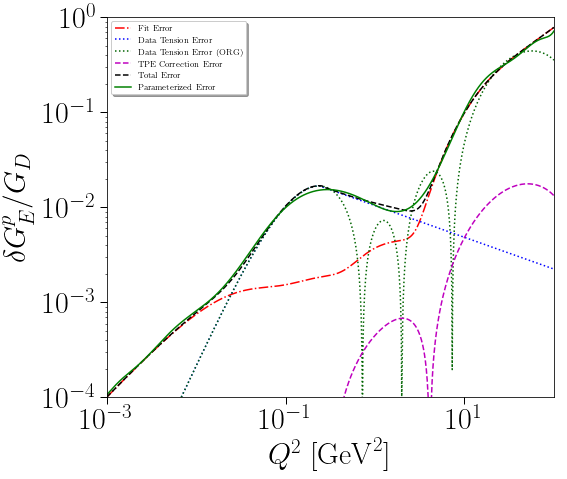

In [35]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GE_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GE_err_ts, 'k:', color='darkgreen',  label='Data Tension Error (ORG)', linewidth=1.5)

axes.plot(Q2, GE_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GE_err_sum, 'k--', color='k',  label='Total Error', linewidth=1.5)
#axes.plot(Q2, GE_err_org, 'k--', color='purple',  label='Total Error (ORG)', linewidth=1.5)

axes.plot(Q2, GE_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
#axes.set_xlim(1e-1, 5e0)

axes.set_ylim(1e-4, 1e0)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^p/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GEp_Error_Curves_sep272019_RE8414.pdf',bbox_inches='tight')

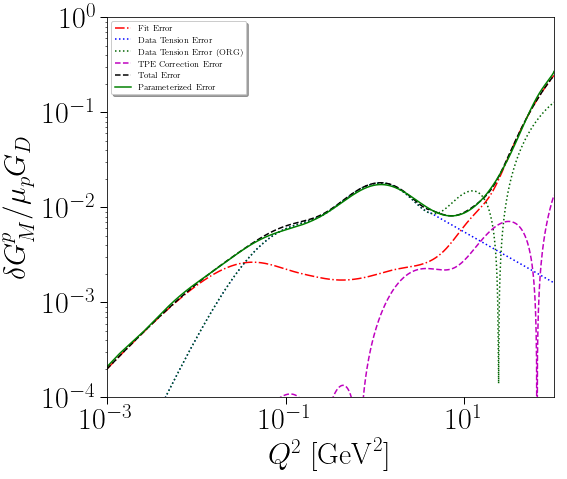

In [36]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD
axes.plot(Q2, GM_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GM_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GM_err_ts, 'k:', color='darkgreen',  label='Data Tension Error (ORG)', linewidth=1.5)
axes.plot(Q2, GM_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GM_err_sum, 'k--', color='k',  label='Total Error', linewidth=1.5)
#axes.plot(Q2, GM_err_org, 'k--', color='purple',  label='Total Error (ORG)', linewidth=1.5)
axes.plot(Q2, GM_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
#axes.set_xlim(0.2,15)
axes.set_ylim(1e-4, 1)
#axes.set_xlim(1e-6, 1e6)
#axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^p/\mu_p G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GMp_Error_Curves_sep272019_RE8414.pdf',bbox_inches='tight')

# Plot Central Values

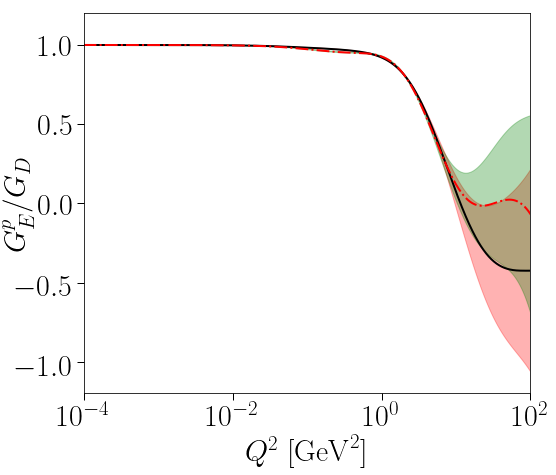

In [37]:
## Plot GE/GD, GM/muGD and GE/GM##########{{{
#Plot Range{{{
ymin1 =-1.2
ymax1 = 1.2 
#}}}

com1 = 'kmax=12'
com2 = 'kmax=12'
#com2 = 'kmax=12, no-High-Q2-Point'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########
axes.plot(Q2, GE_fit_rat, 'k-', color='k', linewidth=2, label=com1)
axes.fill_between(Q2, GE_neg_rat, GE_pos_rat, edgecolor='r',facecolor='r',alpha=0.3)

axes.plot(Q2, GE_fit_rat_WP, 'k-.', color='r', linewidth=2, label=com1)
axes.fill_between(Q2, GE_neg_rat_WP, GE_pos_rat_WP, edgecolor='g',facecolor='g',alpha=0.3)

axes.set_xlim(1e-4,100.)
#axes.set_xlim(Q2_min,Q2_max)
#axes.set_ylim(ymin1,ymax1)
axes.set_ylim(-1.2,1.2)
#axes.set_ylim(0.8,1.05)

axes.set_xscale('log')
axes.set_ylabel('$G_E^p/G_{D}$', fontsize=30) # label, y-axis
axes.yaxis.set_label_coords(-0.1,0.5)
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30) # label, x-axis

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=30)


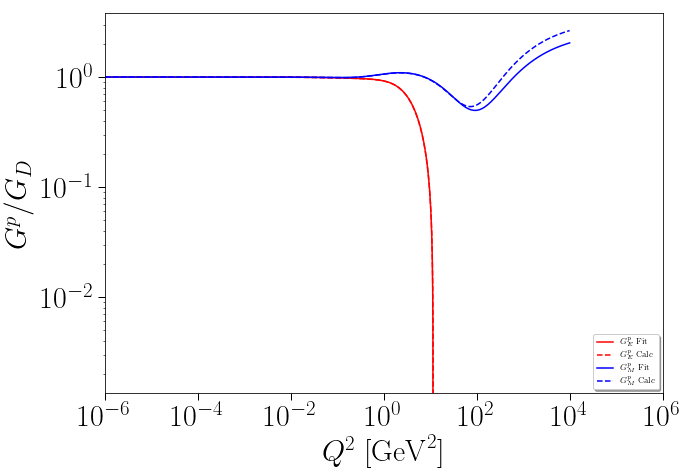

In [26]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_fit/GEd, 'k-', color='r',  label='$G_E^p$ Fit', linewidth=1.5)
axes.plot(Q2, GE_fit_rh, 'k--', color='r',  label='$G_E^p$ Calc', linewidth=1.5)

axes.plot(Q2, GM_fit/GMd, 'k-', color='b',  label='$G_M^p$ Fit', linewidth=1.5)
axes.plot(Q2, GM_fit_rh, 'k--', color='b',  label='$G_M^p$ Calc', linewidth=1.5)

axes.set_xlim(1e-6, 1e6)
#axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G^p/G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

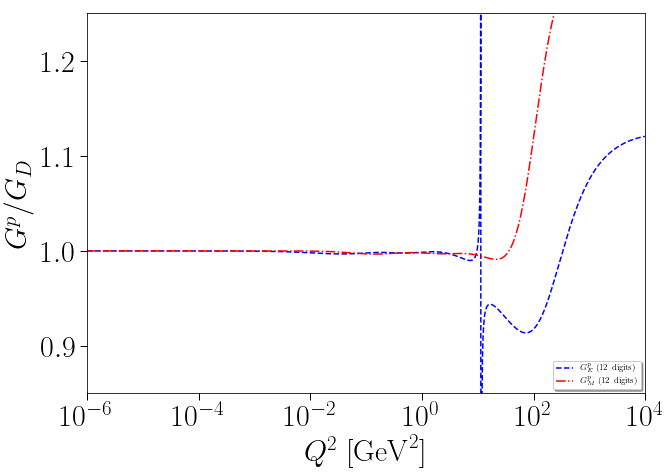

In [27]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)
ND=12
#######  Subplot for GE/GD.
axes.plot(Q2, GE_fit_rh/GE_fit_rat, 'k--', color='b',  label='$G_E^p$  (%d digits)'%ND, linewidth=1.5)
axes.plot(Q2, GM_fit_rh/GM_fit_rat, 'k-.', color='r',  label='$G_M^p$  (%d digits)'%ND, linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(0.85,1.25)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G^p/G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

plt.savefig('proton_central_curve_%d_digits.pdf'%ND,bbox_inches='tight')
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

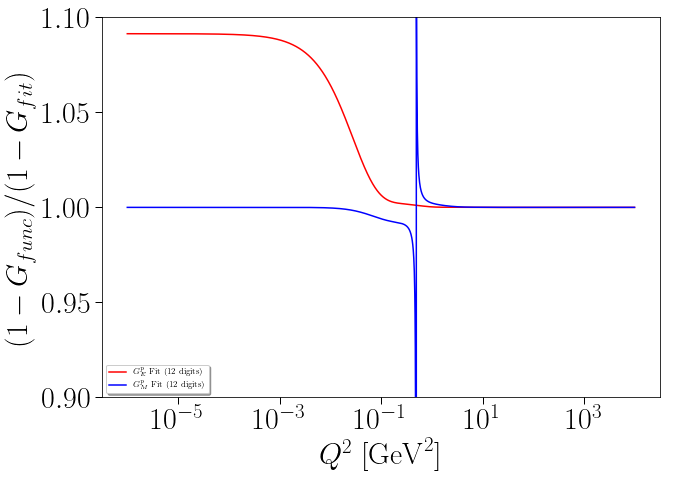

In [28]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, (1.-GE_fit_rh*GEd)/(1.-GE_fit), 'k-', color='r',  label='$G_E^p$ Fit (%d digits)'%ND, linewidth=1.5)

axes.plot(Q2, (1.-GM_fit_rh*GMd)/(1.-GM_fit), 'k-', color='b',  label='$G_M^p$ Fit (%d digits)'%ND, linewidth=1.5)

#axes.set_xlim(2000, 2200)
axes.set_ylim(0.9, 1.1)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$(1-G_{func})/(1-G_{fit})$', fontsize=30)

lg= axes.legend(loc='lower left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc=' right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('proton_central_curve_%d_digits_ratio.pdf'%ND,bbox_inches='tight')
